# <a id='toc1_'></a>[Supplemental material code](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Supplemental material code](#toc1_)    
  - [Intro](#toc1_1_)    
  - [Verify calculations with simulated data](#toc1_2_)    
    - [Distribution of x1, x2, x3](#toc1_2_1_)    
    - [Check the combined distribution](#toc1_2_2_)    
    - [Check the expectation value](#toc1_2_3_)    
    - [Plot a scatter plot of x1 vs x2](#toc1_2_4_)    
  - [Compute the correction factor for sigma_meas](#toc1_3_)    
    - [Correction depends on sig_pop](#toc1_3_1_)    
    - [Function for correcting $\sigma$](#toc1_3_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_1_'></a>[Intro](#toc0_)
This notebook belongs to the Supplemental Material from the paper Understanding the impact of conditionally repeated hemoglobin measurements in the Netherlands by Mart Pothast, Katja vd Hurk & Mart Janssen.

This notebook shows that
- the compuations describe simulated data
- The correction factor for determining the measurement uncertainty from repeated measurements

To run the notebook you need numpy, pandas, matplotlib, scipy, seaborn and numba

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.integrate import nquad
from scipy.optimize import curve_fit

# All the magic happens here, see for implementations of pdfs of distributions
from cond_distr import *

## <a id='toc1_2_'></a>[Verify calculations with simulated data](#toc0_)
The procedure is simple: sample a true Hb from a TRUE~Normal(MU, SIG_POP) distribution and add noise by sampling from another MEAS~Normal(TRUE, SIG_MEAS) distribution with the measurement uncertainty. Then make 3 measurements and save only those that have a previous measurement below the threshold CUT.

In [120]:
N = 1000000
MU = 8.5
SIG_POP = 0.5
CUT = 7.8
SIG_MEAS = 0.4
SIG_TOTAL = np.sqrt(SIG_POP**2 + SIG_MEAS**2)
RHO = SIG_POP**2 / (SIG_POP**2 + SIG_MEAS**2)

true = np.random.normal(MU, SIG_POP, N)
x1, x2, x3 = np.round(np.random.normal(true, SIG_MEAS, (3, len(true))), 1)
print("Check the correlation coeff between the measurments")
print(RHO, np.corrcoef(x1, x2)[0, 1], np.corrcoef(x2, x3)[0, 1])

Check the correlation coeff between the measurments
0.6097560975609756 0.6092827553058245 0.6099279901348468


### <a id='toc1_2_1_'></a>[Distribution of x1, x2, x3](#toc0_)
When conditionally repeated

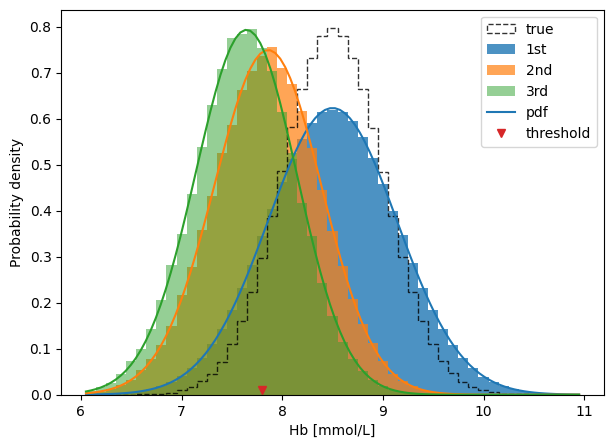

In [121]:
f, ax = plt.subplots(1, figsize=(7, 5))
bins = np.arange(6.05, 11., 0.1)
ax.hist(true, bins=bins, density=True, histtype='step', label='true', color='k', alpha=0.8, ls='--')
ax.hist(x1, bins=bins, density=True, alpha=0.8, label='1st')
ax.hist(x2[x1 < CUT], bins=bins, density=True, alpha=0.7, label='2nd')
ax.hist(x3[(x1 < CUT)&(x2 <CUT)], bins=bins, density=True, alpha=0.5, label='3rd')
xs = np.linspace(bins[0], bins[-1], 100)
ax.plot(xs, scistats.norm.pdf(xs, MU, SIG_TOTAL), 'C0-', label='pdf')
ax.plot(xs, pdf_cond_2nd_meas(xs, MU, SIG_TOTAL, RHO, CUT-0.05), 'C1-')
ax.plot(xs, pdf_cond_3rd_meas(xs, MU, SIG_TOTAL, RHO, CUT-0.05), 'C2-')
ax.plot(CUT, 0.01, marker='v', ls='', label='threshold')
ax.legend()
ax.set(xlabel='Hb [mmol/L]', ylabel='Probability density')
plt.savefig('Simulation_check_x123.pdf', bbox_inches='tight')

### <a id='toc1_2_2_'></a>[Check the combined distribution](#toc0_)
If the max of 3 is taken and stored the distribution looks like this

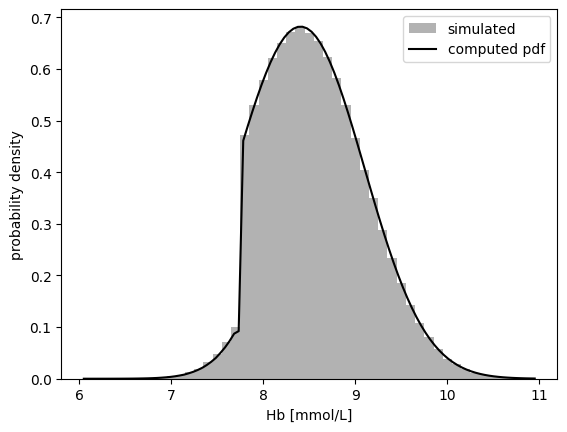

In [122]:
x = x1.copy()
x[x < CUT] = x2[x<CUT]
x[x < CUT] = x3[x < CUT]
x[x <CUT] = np.max([x1, x2, x3], axis=0)[x < CUT]
f, ax = plt.subplots(1)

ax.hist(x, bins=bins, color='k', alpha=0.3, density=True, label='simulated')
ax.plot(xs, pdf_comb(xs, MU, SIG_TOTAL, RHO, CUT), color='k', label='computed pdf')
ax.set(xlabel='Hb [mmol/L]', ylabel='probability density')
ax.legend()
plt.savefig('Simulation_check_xcomb.pdf', bbox_inches='tight')

### <a id='toc1_2_3_'></a>[Check the expectation value](#toc0_)

In [123]:
print("expectation value for x1 and x2 given the conditional")
print(np.mean(x1[x1 < CUT]), ev_x_func(MU, SIG_TOTAL, CUT))

print(np.mean(x2[x1 < CUT]), ev_y_func(MU, SIG_TOTAL, RHO, CUT))

expectation value for x1 and x2 given the conditional
7.430439742106135 7.475314467407268
7.8498305505042145 7.875191748419065


### <a id='toc1_2_4_'></a>[Plot a scatter plot of x1 vs x2](#toc0_)

[0.00489809 0.0489835  0.24507725]


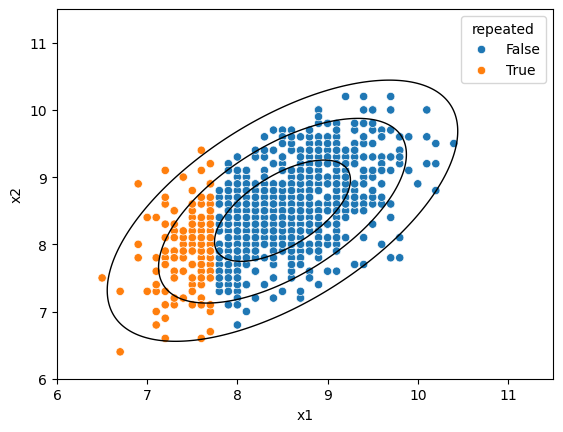

In [133]:
import seaborn as sns

ri = np.random.randint(0, N, 1000)
data = pd.DataFrame(
    dict(x1=x1[ri], x2=x2[ri], repeated=x1[ri] < CUT)
)  # .melt(id_vars=['x1', 'x2'])
fax = sns.scatterplot(
    data,
    x="x1",
    y="x2",
    hue="repeated",
    # kind="scatter",
    # marginal_kws=dict(common_norm=False),
)
rv = scistats.multivariate_normal(
    [MU, MU], [[SIG_TOTAL**2, RHO * SIG_TOTAL**2], [RHO * SIG_TOTAL**2, SIG_TOTAL**2]]
)
x, y = np.mgrid[4:14:0.01, 4:14:0.01]
pos = np.dstack((x, y))
Z = rv.pdf(pos)
Z_flat = Z.flatten()
Z_sorted = np.sort(Z_flat)
cdf = np.cumsum(Z_sorted)
cdf /= cdf[-1]
levels = Z_sorted[np.searchsorted(cdf, (1 - np.array([0.5, 0.9, 0.99])))][::-1]
print(levels)
ax = fax.axes
ax.contour(x, y, Z, levels=levels, colors="k", linewidths=1, linestyles="-")
ax.set(xlim=(6, 11.5), ylim=(6, 11.5))
plt.savefig('scatter.pdf', bbox_inches='tight')

## <a id='toc1_3_'></a>[Compute the correction factor for sigma_meas](#toc0_)
When calculating sigma meas from x1 and x2, and x2 is only available if x1 < cut


In [125]:
def compute_var_diff_xy(mu_pop, sig_pop, sig_meas, cut):
    "Compute variance between x1-x2"
    sig_total = np.sqrt(sig_pop**2 + sig_meas**2)
    rho = sig_pop**2 / sig_total**2
    limits = [[-np.inf, cut], [-np.inf, np.inf]]
    norm = norm_cdf(cut, mu_pop, sig_total)
    ev_x = ev_x_func(mu_pop, sig_total, cut)
    ev_y = ev_y_func(mu_pop, sig_total, rho, cut)

    var_x = nquad(
        lambda x, y: (x - ev_x) ** 2
        * bivariate_normal(x, y, mu_pop, mu_pop, sig_total, sig_total, rho)
        / norm,
        limits,
    )[0]
    var_y = nquad(
        lambda x, y: (y - ev_y) ** 2
        * bivariate_normal(x, y, mu_pop, mu_pop, sig_total, sig_total, rho)
        / norm,
        limits,
    )[0]
    cov = nquad(
        lambda x, y: (x - ev_x)
        * (y - ev_y)
        * bivariate_normal(x, y, mu_pop, mu_pop, sig_total, sig_total, rho)
        / norm,
        limits,
    )[0]
    var_diff_x_y = var_x + var_y - 2 * cov
    # Checked that these are all OK
    return var_diff_x_y


def MC_sig_from_diff(mu_pop, sig_pop, sig_meas, cut, N=1000000):
    # Calc std(x1-x2) from MC samples
    sig = (sig_pop**2 + sig_meas**2) ** 0.5
    rho = sig_pop**2 / sig**2
    x1, x2 = np.random.multivariate_normal(
        [mu_pop, mu_pop], [[sig**2, sig**2 * rho], [sig**2 * rho, sig**2]], size=N
    ).T
    return np.std(x2[x1 < cut] - x1[x1 < cut]) / np.sqrt(2)


# Assert that MC is same as calculated
assert np.isclose(
    np.sqrt(compute_var_diff_xy(9.4, 0.5, 0.4, 8.4) / 2),
    MC_sig_from_diff(9.4, 0.5, 0.4, 8.4),
    rtol=0.1,
    atol=0.1,
)

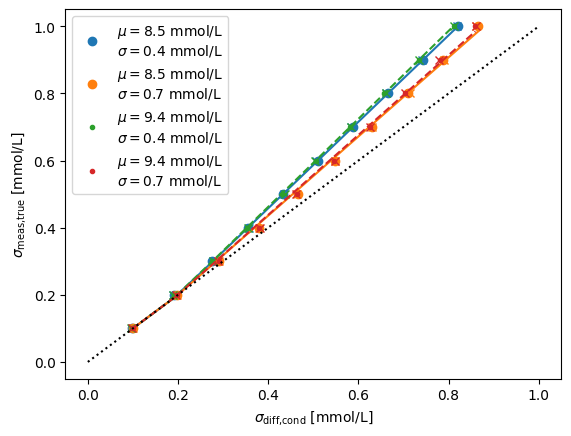

In [126]:
f, ax = plt.subplots(1)

sig_meas_space = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
d_fit = {}
    
sig_pops = np.array([0.4, 0.5, 0.6, 0.7])

CUT_WHERE_FLAT = 0.2
fitfunc = lambda x, a: np.where(
    x > CUT_WHERE_FLAT, CUT_WHERE_FLAT + a * (x - CUT_WHERE_FLAT), x
)
mu_pops = [8.5, 9.4]
cuts = [7.8, 8.4]

for mu_pop, cut, ls, marker in zip(mu_pops, cuts, ["-", "--"], ["o", "."]):
    d_fit[mu_pop] = {}

    for sig_pop in sig_pops:
        sig_meas_from_diff = [
            np.sqrt(compute_var_diff_xy(mu_pop, sig_pop, sig_meas_i, cut) / 2)
            for sig_meas_i in sig_meas_space
        ]
        sig_meas_from_diff_MC = [
            MC_sig_from_diff(mu_pop, sig_pop, sig_meas_i, cut, N=100000)
            for sig_meas_i in sig_meas_space
        ]
        popt, pcov = curve_fit(
            fitfunc, np.array(sig_meas_from_diff), sig_meas_space, p0=[1.3]
        )
        perr = np.sqrt(np.diag(pcov))
        d_fit[mu_pop][sig_pop] = [popt[0], perr[0]]
        if sig_pop in [0.4, 0.7]:
            pl = ax.plot(
                sig_meas_from_diff[:],
                sig_meas_space[:],
                label=f"$\\mu = {mu_pop:.1f}$ mmol/L\n$\\sigma = {sig_pop:.1f}$ mmol/L",
                ls="",
                marker=marker,
            )
            ax.plot(
                sig_meas_from_diff,
                fitfunc(np.array(sig_meas_from_diff), *popt),
                ls=ls,
                color=pl[0].get_color(),
            )
            ax.plot(
                sig_meas_from_diff_MC,
                sig_meas_space,
                color=pl[0].get_color(),
                marker="x",
                ls="",
            )
        # print(popt, perr)

ax.set_xlabel("$\\sigma_{\\text{diff,cond}}$ [mmol/L]")
ax.set_ylabel("$\\sigma_{\\text{meas,true}}$ [mmol/L]")
ax.plot([0, max(sig_meas_space)], [0, max(sig_meas_space)], "k:")
ax.legend()
# plt.savefig('correction_std_fit.pdf', bbox_inches='tight')

### <a id='toc1_3_1_'></a>[Correction depends on sig_pop](#toc0_)
Mildly

[ 1.47546718 -0.41501693] [0.00886032 0.01868059]
[ 1.43935685 -0.37854244] [0.00774123 0.01635706]


Text(0.5, 0, '$\\sigma_{\\text{pop}}$ [mmol/L]')

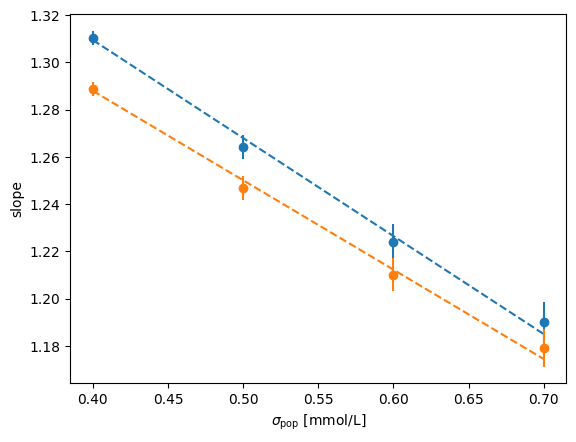

In [127]:
f, ax = plt.subplots(1)
slope_1 = np.array([val[0] for key, val in d_fit[9.4].items()])
slope_1_err = np.array([val[1] for key, val in d_fit[9.4].items()])
pl = ax.errorbar(sig_pops, slope_1, yerr=slope_1_err, ls="", marker="o")

fit_func = lambda x, a, b: a + b * x
popt, pcov = curve_fit(fit_func, sig_pops, slope_1, sigma=slope_1_err)
print(popt, np.sqrt(np.diag(pcov)))
ax.plot(sig_pops, fit_func(sig_pops, *popt), color=pl[0].get_color(), ls="--")
slope_2 = np.array([val[0] for key, val in d_fit[8.5].items()])
slope_2_err = np.array([val[1] for key, val in d_fit[8.5].items()])

popt, pcov = curve_fit(fit_func, sig_pops, slope_2, sigma=slope_2_err)
print(popt, np.sqrt(np.diag(pcov)))

pl = ax.errorbar(
    sig_pops,
    slope_2,
    yerr=slope_2_err,
    ls="",
    marker="o",
)
ax.plot(sig_pops, fit_func(sig_pops, *popt), color=pl[0].get_color(), ls="--")
ax.set_ylabel("slope")
ax.set_xlabel("$\\sigma_{\\text{pop}}$ [mmol/L]")
# plt.savefig("slope_sig_meas_diff.pdf", bbox_inches="tight")

### <a id='toc1_3_2_'></a>[Function for correcting $\sigma$](#toc0_)
$$
\sigma_{\text{meas}} = \begin{cases}
    \sigma_{diff,cut} & \text{, for } \sigma_{diff,cut} \leq 0.2 \\
0.2 + (\sigma_{diff,cut}-0.2)(1.468 - 0.40 \sigma_{\text{pop}}) & \sigma_{diff,cut} > 0.2 \text{ and } \mu_{\text{pop}} = 9.4 \\
0.2 + (\sigma_{diff,cut}-0.2)(1.433- 0.37 \sigma_{\text{pop}}) & \sigma_{diff,cut} > 0.2 \text{ and } \mu_{\text{pop}} = 8.5
\end{cases}
$$